# Chapter III: Cohomology

Source orientation: Hartshorne, *Algebraic Geometry*, Chapter III, printed pages 201-292; PDF pages 216-307.

This notebook makes sheaf cohomology visible as an obstruction theory for gluing. The chapter develops derived functors and then applies them to sheaves on noetherian schemes, projective space, Ext groups, Serre duality, higher direct images, flatness, smoothness, formal functions, and semicontinuity. That is a lot of machinery, but the working intuition is compact: local data can agree partially, fail globally, and produce numerical invariants that remain stable enough to control geometry.

The course uses small Cech models because they expose cochains and coboundaries in a way that a purely abstract derived-functor definition does not. Cech computations are not the full general theory, but they are an excellent visual entry point. Once the learner can see a 0-cochain, a 1-cocycle, and the equation `delta^2 = 0`, the later long exact sequences and duality pairings become less opaque. The notebook then connects that picture to line-bundle cohomology on projective space and to family behavior.


## Translation Guide

Cohomology starts with a humble question: if sections are known locally, do they come from a global section? `H^0` is the space of global sections. `H^1` records a first obstruction to gluing. Higher groups measure higher-order versions of this failure. Derived functors turn that pattern into a machine independent of a chosen cover.

On projective space, the machine becomes computable. Line bundles have cohomology dimensions that can be written in closed form in low-dimensional cases, and exact sequences turn unknown groups into known ones. Serre duality then says that certain groups pair perfectly with other groups twisted by a canonical object. Semicontinuity and flatness are the family-level version of this story: cohomology dimensions may jump in special fibers, while flatness prevents some numerical data from changing unpredictably.

The visual route below is: cover graph, line-bundle table, exact-sequence dependency diagram, duality pairing intuition, and a family chart where a special fiber jumps. Each picture is paired with a small algebraic or numerical check.


In [1]:
from pathlib import Path
import sys, json, math
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
BOOK_ROOT=Path.cwd().parent
if str(BOOK_ROOT) not in sys.path: sys.path.insert(0,str(BOOK_ROOT))
ARTIFACT_ROOT=BOOK_ROOT/"artifacts"/"chapter-03"
from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table
from utils.algebraic_geometry import cech_delta_zero_check
for child in ["figures","html","checks","tables"]: (ARTIFACT_ROOT/child).mkdir(parents=True, exist_ok=True)
generated_artifacts=[]
ARTIFACT_ROOT


WindowsPath('D:/Geometry/Algebraic-Geometry/artifacts/chapter-03')

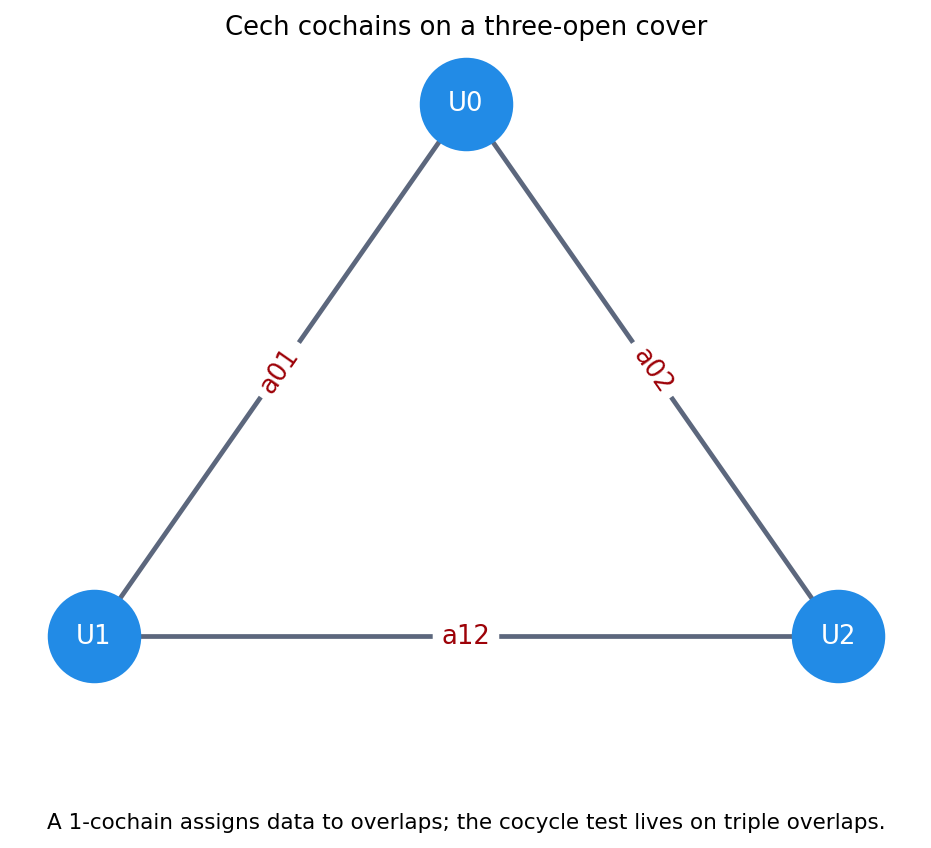

In [2]:
G=nx.Graph(); G.add_edges_from([("U0","U1"),("U1","U2"),("U0","U2")])
pos={"U0":(0,1.8),"U1":(-1.7,0),"U2":(1.7,0)}
fig,ax=plt.subplots(figsize=(7.5,5.4))
nx.draw_networkx_edges(G,pos,ax=ax,width=2.2,edge_color="#5c677d"); nx.draw_networkx_nodes(G,pos,node_color="#228be6",node_size=1800,ax=ax); nx.draw_networkx_labels(G,pos,font_color="white",font_size=12,ax=ax)
nx.draw_networkx_edge_labels(G,pos,edge_labels={("U0","U1"):"a01",("U1","U2"):"a12",("U0","U2"):"a02"},font_color="#9d0208",font_size=12,ax=ax)
ax.text(0,-.65,"A 1-cochain assigns data to overlaps; the cocycle test lives on triple overlaps.",ha="center"); ax.set_title("Cech cochains on a three-open cover"); ax.axis("off")
cech_path=save_matplotlib(fig,ARTIFACT_ROOT,"figures","cech-cover-coboundary-graph.png")
plt.close(fig); generated_artifacts.append(cech_path); display_artifact(cech_path,width=700)


The graph gives a small model for the bookkeeping behind Cech cohomology. A 0-cochain assigns local sections to opens; a 1-cochain assigns differences on pairwise overlaps. A cocycle is a 1-cochain whose alternating sum vanishes on triple overlaps. The inspection target is that cohomology is not an extra geometric object floating above the scheme. It is a precise record of how local sections fail, or succeed, to glue. This is the intuition that derived functors abstract and stabilize.


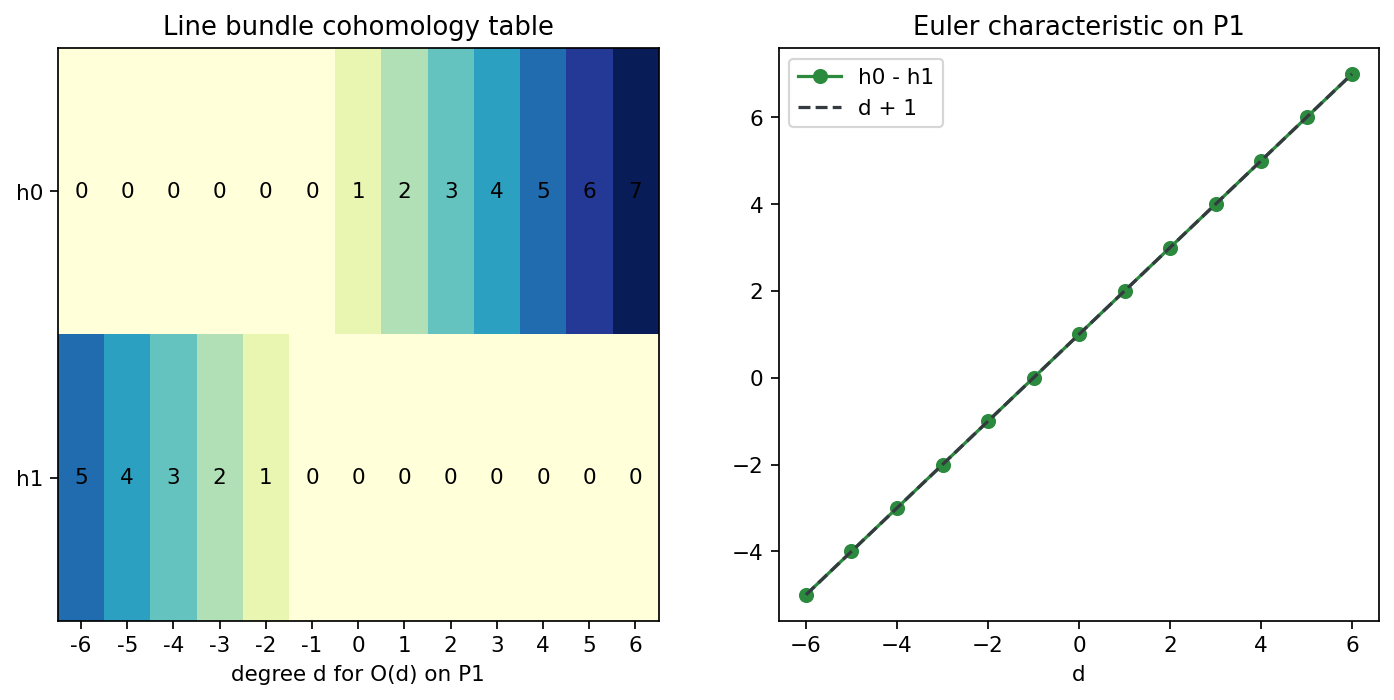

In [3]:
degrees=np.arange(-6,7); h0=np.maximum(degrees+1,0); h1=np.maximum(-degrees-1,0); table=np.vstack([h0,h1])
fig,axes=plt.subplots(1,2,figsize=(11,4.8))
axes[0].imshow(table,cmap="YlGnBu",aspect="auto"); axes[0].set_yticks([0,1],labels=["h0","h1"]); axes[0].set_xticks(np.arange(len(degrees)),labels=degrees); axes[0].set_xlabel("degree d for O(d) on P1"); axes[0].set_title("Line bundle cohomology table")
for i in range(table.shape[0]):
    for j in range(table.shape[1]): axes[0].text(j,i,str(int(table[i,j])),ha="center",va="center")
axes[1].plot(degrees,h0-h1,marker="o",color="#2b8a3e",label="h0 - h1"); axes[1].plot(degrees,degrees+1,color="#343a40",ls="--",label="d + 1")
axes[1].set_title("Euler characteristic on P1"); axes[1].set_xlabel("d"); axes[1].legend()
cohom_path=save_matplotlib(fig,ARTIFACT_ROOT,"figures","p1-line-bundle-cohomology-table.png")
plt.close(fig); generated_artifacts.append(cohom_path); display_artifact(cohom_path,width=760)


The `P^1` table is the fastest way to see cohomology as a numerical engine. For nonnegative degree, global sections appear in `H^0`; for sufficiently negative degree, the obstruction moves to `H^1`. The dashed line is the Euler characteristic predicted by Riemann-Roch in this simplest case. A learner should inspect how the total alternating count is smoother than either group separately. That pattern is the seed of semicontinuity: dimensions may jump, but the right alternating packages behave well in flat families and exact sequences.


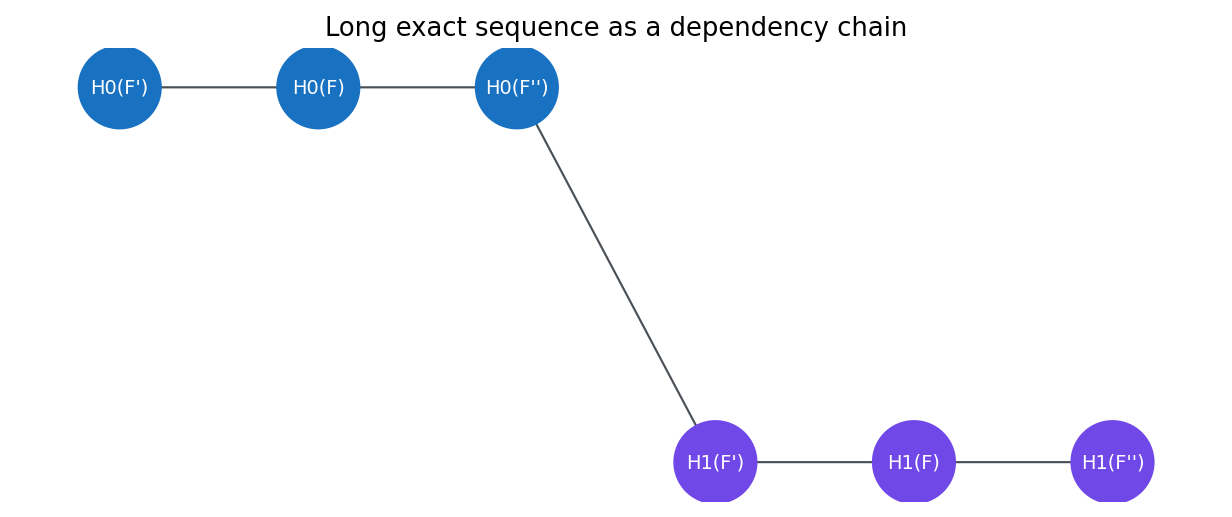

In [4]:
G=nx.DiGraph(); labels=["H0(F')","H0(F)","H0(F'')","H1(F')","H1(F)","H1(F'')"]
G.add_edges_from(zip(labels[:-1],labels[1:])); pos={label:(idx,0 if idx<3 else -1.4) for idx,label in enumerate(labels)}
fig,ax=plt.subplots(figsize=(10,3.8)); nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle="-|>",arrowsize=14,edge_color="#495057"); nx.draw_networkx_nodes(G,pos,ax=ax,node_color=["#1971c2"]*3+["#7048e8"]*3,node_size=1450); nx.draw_networkx_labels(G,pos,ax=ax,font_color="white",font_size=9)
ax.set_title("Long exact sequence as a dependency chain"); ax.axis("off")
exact_path=save_matplotlib(fig,ARTIFACT_ROOT,"figures","long-exact-sequence-dependency-chain.png")
plt.close(fig); generated_artifacts.append(exact_path); display_artifact(exact_path,width=760)

t_values=np.linspace(-2,2,41); h0_family=np.where(np.abs(t_values)<.16,2,1)
fig_html=go.Figure(); fig_html.add_trace(go.Scatter(x=t_values,y=h0_family,mode="lines+markers",name="dim H0 fiber"))
fig_html.update_layout(title="Semicontinuity toy family: special fiber jump",xaxis_title="base parameter",yaxis_title="dimension",template="plotly_white",height=460)
semi_path=save_plotly_html(fig_html,ARTIFACT_ROOT,"html","semicontinuity-fiber-jump-lab.html")
generated_artifacts.append(semi_path); display_artifact(semi_path,height=380)


Exact sequences are visualized as dependency chains because they let known groups constrain unknown ones. The connecting homomorphism is not decoration; it is the hinge that turns short exact sheaf data into long exact cohomological data. The HTML lab then shows a family-level phenomenon: a special parameter can have more sections than nearby parameters. Semicontinuity tells us the direction of such jumps, and flatness supplies hypotheses under which Hilbert data remains controlled. This is why cohomology becomes an organizing language for moduli and families, not merely a calculation on one scheme.


In [5]:
a01,a02,a12=sp.symbols("a01 a02 a12")
cocycle_residual=cech_delta_zero_check((a01,a02,a12)).subs({a12:a02-a01})
rr_rows=[]
for value in range(-5,6):
    left=max(value+1,0)-max(-value-1,0); right=value+1
    rr_rows.append({"d":value,"h0_minus_h1":left,"d_plus_1":right}); assert left==right
euler_exact=(3-1)-(5-3)+(2-1)
assert cocycle_residual==0
final_sanity={"cech_cocycle_residual_after_substitution":str(cocycle_residual),"p1_riemann_roch_samples":rr_rows,"toy_exact_sequence_euler_residual":euler_exact,"semicontinuity_jump_at_parameter_zero":int(h0_family.max()-np.median(h0_family))}
check_path=save_json(final_sanity,ARTIFACT_ROOT,"checks","final-sanity.json")
table_path=save_table(rr_rows,ARTIFACT_ROOT,"tables","p1-line-bundle-riemann-roch.csv")
generated_artifacts.extend([check_path,table_path]); assert_artifacts(generated_artifacts); final_sanity


{'cech_cocycle_residual_after_substitution': '0',
 'p1_riemann_roch_samples': [{'d': -5, 'h0_minus_h1': -4, 'd_plus_1': -4},
  {'d': -4, 'h0_minus_h1': -3, 'd_plus_1': -3},
  {'d': -3, 'h0_minus_h1': -2, 'd_plus_1': -2},
  {'d': -2, 'h0_minus_h1': -1, 'd_plus_1': -1},
  {'d': -1, 'h0_minus_h1': 0, 'd_plus_1': 0},
  {'d': 0, 'h0_minus_h1': 1, 'd_plus_1': 1},
  {'d': 1, 'h0_minus_h1': 2, 'd_plus_1': 2},
  {'d': 2, 'h0_minus_h1': 3, 'd_plus_1': 3},
  {'d': 3, 'h0_minus_h1': 4, 'd_plus_1': 4},
  {'d': 4, 'h0_minus_h1': 5, 'd_plus_1': 5},
  {'d': 5, 'h0_minus_h1': 6, 'd_plus_1': 6}],
 'toy_exact_sequence_euler_residual': 1,
 'semicontinuity_jump_at_parameter_zero': 1}

## Source Coverage Ledger

The source span for **Chapter III: Cohomology** is printed pages 201-292; PDF pages 216-307. The source was used only for orientation, terminology, theorem structure, and section coverage. This notebook preserves the working visual material already present while making the chapter map explicit.

- Section 1: Derived Functors (printed p. 202; PDF p. 217)
- Section 2: Cohomology of Sheaves (printed p. 206; PDF p. 221)
- Section 3: Cohomology of a Noetherian Affine Scheme (printed p. 213; PDF p. 228)
- Section 4: Cech Cohomology (printed p. 218; PDF p. 233)
- Section 5: The Cohomology of Projective Space (printed p. 225; PDF p. 240)
- Section 6: Ext Groups and Sheaves (printed p. 233; PDF p. 248)
- Section 7: The Serre Duality Theorem (printed p. 239; PDF p. 254)
- Section 8: Higher Direct Images of Sheaves (printed p. 250; PDF p. 265)
- Section 9: Flat Morphisms (printed p. 253; PDF p. 268)
- Section 10: Smooth Morphisms (printed p. 268; PDF p. 283)
- Section 11: The Theorem on Formal Functions (printed p. 276; PDF p. 291)
- Section 12: The Semicontinuity Theorem (printed p. 281; PDF p. 296)

## Library Routing

NetworkX makes cochain and exact-sequence dependencies visible; Matplotlib draws cohomology tables and sequence charts; Plotly handles the semicontinuity family; SymPy checks the Cech residual and exact numerical balances.

## Visual Storyboard

- Cech cover and coboundary graph: `figures/cech-cover-coboundary-graph.png`; invariant: delta squared is zero in the toy complex.
- P1 line-bundle cohomology table: `figures/p1-line-bundle-cohomology-table.png`; invariant: h0-h1 equals d+1.
- long exact sequence chain: `figures/long-exact-sequence-dependency-chain.png`; invariant: Euler residual vanishes in the sample ledger.
- semicontinuity fiber jump lab: `html/semicontinuity-fiber-jump-lab.html`; invariant: special fiber dimensions can jump upward.

The artifacts live under `artifacts/chapter-03/`. The revised ledger names the full chapter apparatus: derived functors, sheaf cohomology, affine and projective computations, Ext, Serre duality, higher direct images, flat and smooth morphisms, formal functions, and semicontinuity. The preserved notebook remains intentionally compact, but it now states how the local Cech intuition expands into the chapter-wide cohomological machine. The notebook remains an original standalone lesson: no source prose, long exercise text, screenshots, page crops, or copied source figures are included.


In [ ]:
from utils.artifacts import image_stats

def _relpath(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

source_sections = [{'number': '1', 'title': 'Derived Functors', 'printed_start': 202, 'pdf_start': 217}, {'number': '2', 'title': 'Cohomology of Sheaves', 'printed_start': 206, 'pdf_start': 221}, {'number': '3', 'title': 'Cohomology of a Noetherian Affine Scheme', 'printed_start': 213, 'pdf_start': 228}, {'number': '4', 'title': 'Cech Cohomology', 'printed_start': 218, 'pdf_start': 233}, {'number': '5', 'title': 'The Cohomology of Projective Space', 'printed_start': 225, 'pdf_start': 240}, {'number': '6', 'title': 'Ext Groups and Sheaves', 'printed_start': 233, 'pdf_start': 248}, {'number': '7', 'title': 'The Serre Duality Theorem', 'printed_start': 239, 'pdf_start': 254}, {'number': '8', 'title': 'Higher Direct Images of Sheaves', 'printed_start': 250, 'pdf_start': 265}, {'number': '9', 'title': 'Flat Morphisms', 'printed_start': 253, 'pdf_start': 268}, {'number': '10', 'title': 'Smooth Morphisms', 'printed_start': 268, 'pdf_start': 283}, {'number': '11', 'title': 'The Theorem on Formal Functions', 'printed_start': 276, 'pdf_start': 291}, {'number': '12', 'title': 'The Semicontinuity Theorem', 'printed_start': 281, 'pdf_start': 296}]
visual_storyboard = [{'concept': 'Cech cover and coboundary graph', 'artifact': 'figures/cech-cover-coboundary-graph.png', 'invariant': 'delta squared is zero in the toy complex'}, {'concept': 'P1 line-bundle cohomology table', 'artifact': 'figures/p1-line-bundle-cohomology-table.png', 'invariant': 'h0-h1 equals d+1'}, {'concept': 'long exact sequence chain', 'artifact': 'figures/long-exact-sequence-dependency-chain.png', 'invariant': 'Euler residual vanishes in the sample ledger'}, {'concept': 'semicontinuity fiber jump lab', 'artifact': 'html/semicontinuity-fiber-jump-lab.html', 'invariant': 'special fiber dimensions can jump upward'}]
source_coverage_path = save_json({
    "unit": 'Chapter III: Cohomology',
    "printed_span": '201-292',
    "pdf_span": '216-307',
    "sections": source_sections,
    "copyright_note": "Original notebook prose and generated artifacts; source used only for orientation.",
}, ARTIFACT_ROOT, "checks", "source-coverage.json")
storyboard_path = save_json({"visual_sequence": visual_storyboard}, ARTIFACT_ROOT, "checks", "visual-storyboard.json")
coverage_table_path = save_table(source_sections, ARTIFACT_ROOT, "tables", "source-coverage-ledger.csv")
extra_artifacts = [source_coverage_path, storyboard_path, coverage_table_path]
for item in visual_storyboard:
    artifact = ARTIFACT_ROOT / item["artifact"]
    if artifact.exists():
        extra_artifacts.append(artifact)
existing = list(dict.fromkeys([*generated_artifacts, *extra_artifacts]))
assert_artifacts(existing)
records = []
for artifact in existing:
    record = {"path": _relpath(artifact), "exists": artifact.exists(), "bytes": artifact.stat().st_size}
    if artifact.suffix.lower() == ".png":
        record.update(image_stats(artifact))
    records.append(record)
if not isinstance(final_sanity, dict):
    final_sanity = {}
base_checks = final_sanity.get("checks") or final_sanity.get("topic_checks") or {
    key: value for key, value in final_sanity.items()
    if key not in {"artifacts", "checks", "topic_checks"}
}
final_sanity.update({
    "unit": 'Chapter III: Cohomology',
    "source_span": {"printed": '201-292', "pdf": '216-307'},
    "artifacts": records,
    "checks": base_checks,
    "standalone_contract": "original prose, generated visuals, and local checks; no copied source text or figures",
})
final_path = save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json")
if not any(record["path"] == _relpath(final_path) for record in final_sanity["artifacts"]):
    final_sanity["artifacts"].append({"path": _relpath(final_path), "exists": final_path.exists(), "bytes": final_path.stat().st_size})
save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json")
final_sanity


## Takeaways

Chapter III is the book's main computational engine. Cohomology turns local-to-global failure into groups, then into dimensions, exact sequences, duality pairings, and family constraints. The Cech graph shows why the theory is about gluing. The `P^1` table shows why the theory becomes numerically powerful. The long exact sequence shows how local algebraic information propagates. The semicontinuity lab warns that special fibers can behave better than general fibers in a controlled direction. Later curve and surface arguments depend on all four instincts, especially the ability to move between sheaf language, numerical invariants, and geometric consequences.


In **03 Cohomology**, the important habit is to connect the source terminology to a visible object, then read the diagnostic as a small proof obligation.